# РОЗРАХУНКОВО-ГРАФIЧНА РОБОТА

In [16]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Постановка задачі:

Потрібно розв’язати рівняння Лапласа:

$$
\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}=0,
$$

в області

$$
0<x<L_1,\qquad 0<y<L_2.
$$

In [17]:
L1 = 1.0
L2 = 1.0

### Точним розв’язком є функція

$$
u(x,y)=a(x^2-y^2)+bxy+cx+dy+f,
$$

де

$$
a=0.3,\qquad b=0.3,\qquad c=1.1,\qquad d=1.5,\qquad f=0.9.
$$

In [18]:
a = 0.3
b = 0.3
c = 1.1
d = 1.5
f = 0.9

In [19]:
def exact_solution(x, y):
    return a * (x**2 - y**2) + b * x * y + c * x + d * y + f

### Крайові умови
$$
u_x(0,y)=F;
$$

$$
u(L_1,y)+u_x(L_1,y)=G;
$$

$$
u(x,0)-u_y(x,0)=H;
$$

$$
u(x,L_2)=K.
$$

In [20]:
def F(y):
    return 2 * a * 0 + b * y + c

def G(y):
    u = exact_solution(L1, y)
    ux = 2 * a * L1 + b * y + c
    return u + ux

def H(x):
    u = exact_solution(x, 0)
    uy = -2 * a * 0 + b * x + d
    return u - uy

def K(x):
    return exact_solution(x, L2)

## 2. Побудова сітки

In [51]:
N = 40
M = 40

x = np.linspace(0, L1, N + 1)
y = np.linspace(0, L2, M + 1)

U = np.zeros((N + 1, M + 1))

## 3. Задання граничних умов

In [52]:
for i in range(N + 1):
    U[i, M] = K(x[i])

for i in range(N + 1):
    for j in range(M + 1):
        U[i, j] = 0.0

for i in range(N + 1):
    U[i, M] = K(x[i])

## 4. Метод Лібмана

In [53]:
hx = L1 / N
hy = L2 / M

eps = 1e-6

max_iter = 10000

In [54]:
iterations = 0

saved_iterations = {}
errors_iter = []

for k in range(max_iter):

    U_old = U.copy()

    for j in range(1, M):
        U[0, j] = U[1, j] - hx * F(y[j])

    for j in range(1, M):
        U[N, j] = (G(y[j]) + (1 / hx) * U[N - 1, j]) / (1 + 1 / hx)

    for i in range(1, N):
        U[i, 0] = (H(x[i]) + (1 / hy) * U[i, 1]) / (1 + 1 / hy)

    for i in range(1, N):
        for j in range(1, M):

            U[i, j] = 0.25 * (
                U[i + 1, j]
                + U[i - 1, j]
                + U[i, j + 1]
                + U[i, j - 1]
            )
            
    if k in [0, 2, 9, 24, 49, 199]:
        saved_iterations[k + 1] = U.copy()

    diff = np.max(np.abs(U - U_old))
    errors_iter.append(diff)

    iterations += 1

    if diff < eps:
        break


## 5. Точний розв'язок та похибка

In [55]:
U_exact = np.zeros_like(U)

for i in range(N + 1):
    for j in range(M + 1):
        U_exact[i, j] = exact_solution(x[i], y[j])

error = np.abs(U - U_exact)

max_error = np.max(error)

## 6. Результат

In [56]:
print("\n")
print("ПЕРШІ ІТЕРАЦІЇ МЕТОДУ ЛІБМАНА")

for it, matrix in saved_iterations.items():

    print(f"\nІтерація №{it}")

    print(np.round(matrix, 3))



ПЕРШІ ІТЕРАЦІЇ МЕТОДУ ЛІБМАНА

Ітерація №1
[[ 0.000e+00 -2.800e-02 -2.800e-02 ... -3.500e-02 -3.500e-02  2.100e+00]
 [-1.400e-02 -1.000e-02 -1.000e-02 ... -1.200e-02  5.220e-01  2.135e+00]
 [-1.400e-02 -6.000e-03 -4.000e-03 ... -4.000e-03  6.720e-01  2.171e+00]
 ...
 [ 1.100e-02  3.000e-03  1.000e-03 ... -0.000e+00  1.228e+00  3.701e+00]
 [ 1.100e-02  2.800e-02  3.200e-02 ...  4.600e-02  1.291e+00  3.750e+00]
 [ 0.000e+00  9.900e-02  1.000e-01 ...  1.400e-01  1.410e-01  3.800e+00]]

Ітерація №3
[[ 0.    -0.047 -0.045 ...  0.078  0.817  2.1  ]
 [-0.033 -0.027 -0.025 ...  0.282  1.055  2.135]
 [-0.025 -0.018 -0.014 ...  0.385  1.162  2.171]
 ...
 [ 0.022  0.024  0.025 ...  0.806  2.106  3.701]
 [ 0.063  0.074  0.078 ...  0.884  2.174  3.75 ]
 [ 0.     0.15   0.156 ...  0.623  1.955  3.8  ]]

Ітерація №10
[[ 0.    -0.091 -0.085 ...  0.879  1.464  2.1  ]
 [-0.076 -0.068 -0.062 ...  0.971  1.531  2.135]
 [-0.059 -0.051 -0.045 ...  1.038  1.585  2.171]
 ...
 [ 0.105  0.108  0.11  ...  1.99

In [57]:
print(f"РЕЗУЛЬТАТИ ОБЧИСЛЕНЬ\n")
print(f"Кількість ітерацій: {iterations}")
print(f"Максимальна похибка: {max_error:.10f}")

print("\nЧисельний розв'язок U:")
print(np.round(U, 4))

print("\nТочний розв'язок:")
print(np.round(U_exact, 4))

print("\nАбсолютна похибка:")
print(np.round(error, 5))

РЕЗУЛЬТАТИ ОБЧИСЛЕНЬ

Кількість ітерацій: 5540
Максимальна похибка: 2.3000000000

Чисельний розв'язок U:
[[0.     0.9378 0.975  ... 2.0551 2.0779 2.1   ]
 [0.9278 0.9655 1.0028 ... 2.0898 2.1127 2.1352]
 [0.9557 0.9936 1.0311 ... 2.1248 2.148  2.1708]
 ...
 [2.2155 2.2601 2.3043 ... 3.6412 3.6712 3.7008]
 [2.2576 2.3024 2.3468 ... 3.6904 3.7205 3.7502]
 [0.     2.3451 2.3897 ... 3.74   3.7703 3.8   ]]

Точний розв'язок:
[[0.9    0.9373 0.9742 ... 2.0542 2.0773 2.1   ]
 [0.9277 0.9652 1.0023 ... 2.0891 2.1123 2.1352]
 [0.9558 0.9934 1.0308 ... 2.1242 2.1477 2.1708]
 ...
 [2.2158 2.2602 2.3042 ... 3.6408 3.6709 3.7008]
 [2.2577 2.3023 2.3466 ... 3.6898 3.7202 3.7502]
 [2.3    2.3448 2.3892 ... 3.7392 3.7698 3.8   ]]

Абсолютна похибка:
[[9.0e-01 5.3e-04 7.1e-04 ... 9.0e-04 5.9e-04 0.0e+00]
 [1.5e-04 3.5e-04 5.2e-04 ... 7.1e-04 4.0e-04 0.0e+00]
 [1.0e-05 1.7e-04 3.5e-04 ... 5.8e-04 3.1e-04 0.0e+00]
 ...
 [2.8e-04 1.0e-04 7.0e-05 ... 4.8e-04 2.6e-04 0.0e+00]
 [1.2e-04 6.0e-05 2.3e-04 ... 6

## 7. Візуалізація

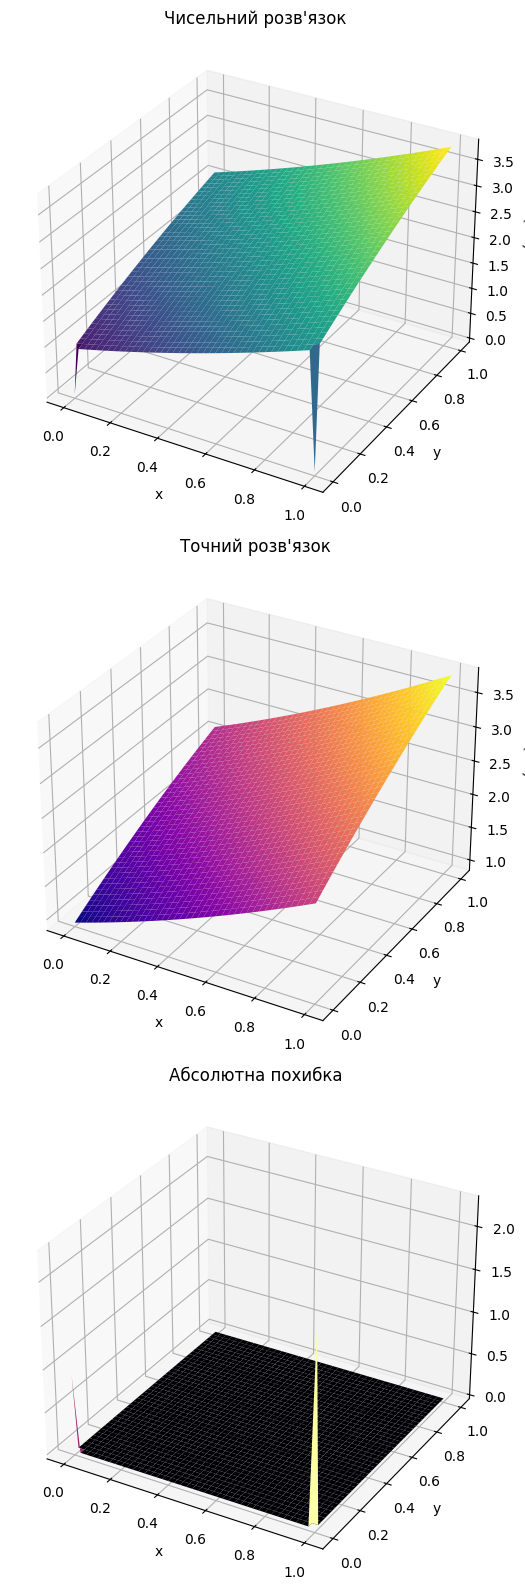

In [39]:
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(7, 16))

ax1 = fig.add_subplot(311, projection='3d')
ax1.plot_surface(X, Y, U.T, cmap='viridis')
ax1.set_title("Чисельний розв'язок")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u(x,y)")

ax2 = fig.add_subplot(312, projection='3d')
ax2.plot_surface(X, Y, U_exact.T, cmap='plasma')
ax2.set_title("Точний розв'язок")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("u(x,y)")

ax3 = fig.add_subplot(313, projection='3d')
ax3.plot_surface(X, Y, error.T, cmap='inferno')
ax3.set_title("Абсолютна похибка")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("error")

plt.tight_layout()

plt.show()

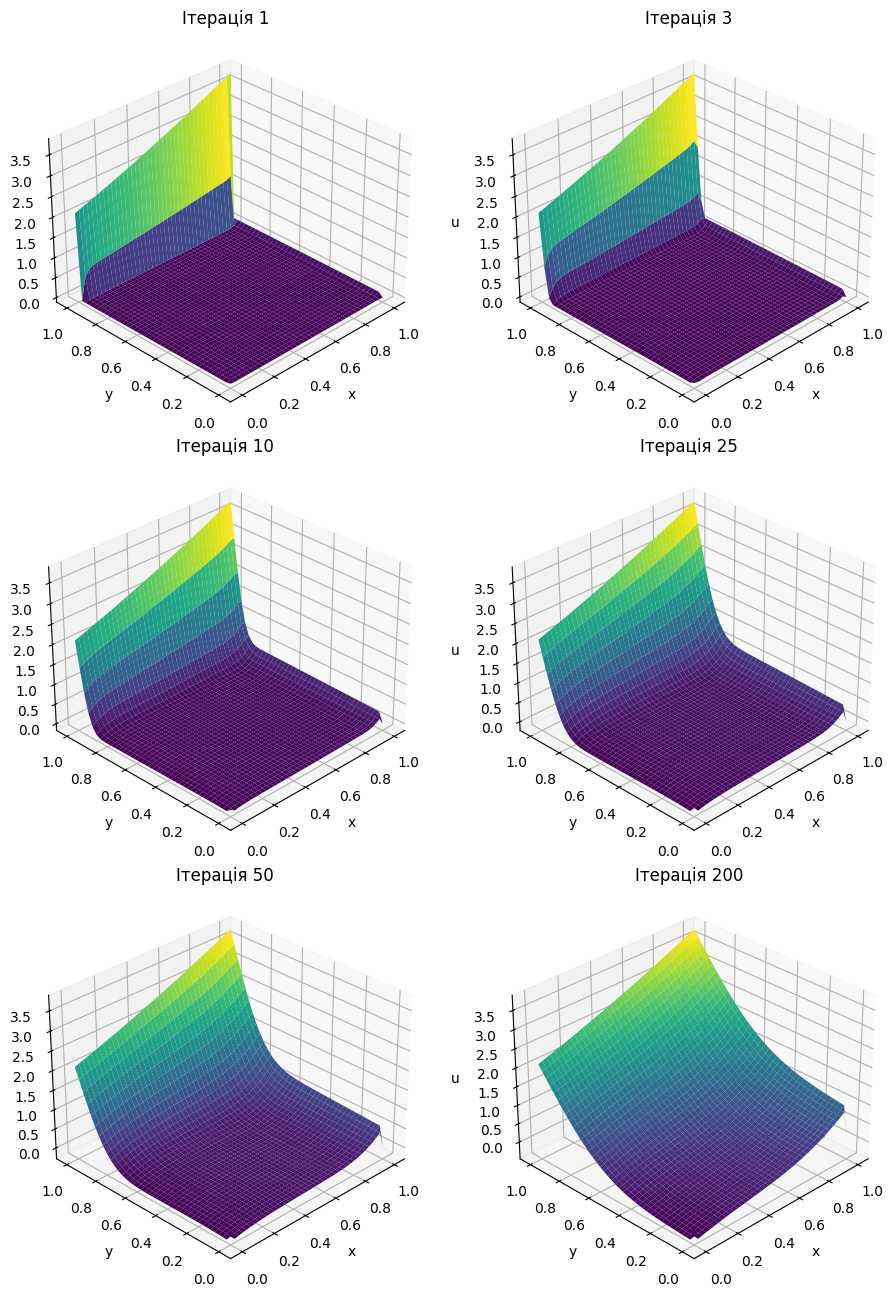

In [ ]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 13),
    subplot_kw={"projection": "3d"}
)

axes = axes.flatten()

selected = list(saved_iterations.keys())

for idx, it in enumerate(selected):

    ax = axes[idx]

    surf = ax.plot_surface(
        X,
        Y,
        saved_iterations[it].T,
        cmap='viridis',
        edgecolor='none'
    )

    ax.set_title(f"Ітерація {it}")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("u")

    ax.view_init(elev=30, azim=-135)

for j in range(len(selected), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

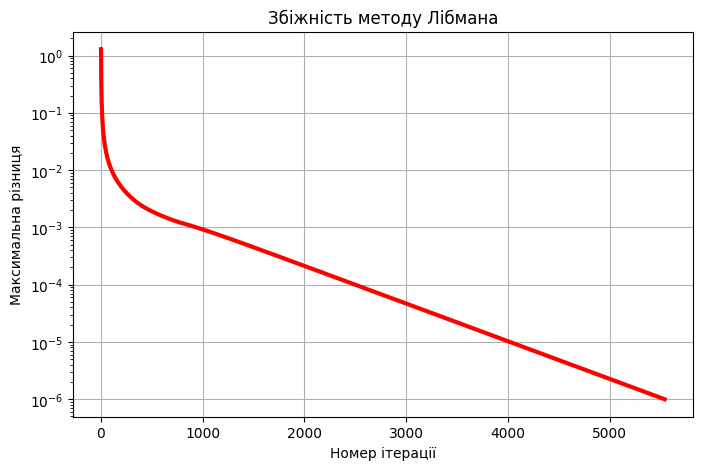

In [58]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    errors_iter,
    color='red',
    linewidth=3
)

plt.title("Збіжність методу Лібмана")
plt.xlabel("Номер ітерації")
plt.ylabel("Максимальна різниця")

plt.grid(True)

plt.show()

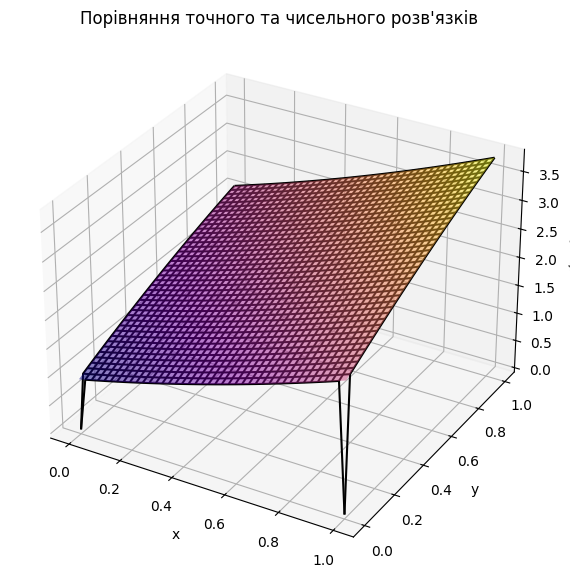

In [ ]:
ax.plot_surface(
    X,
    Y,
    U_exact,
    alpha=0.5,
    cmap='plasma'
)

ax.plot_wireframe(
    X,
    Y,
    U,
    color='black'
)

ax.set_title("Порівняння точного та чисельного розв'язків")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y)")

plt.show()


## 8. Вплив сітки на точність

In [62]:
grid_sizes = [20, 40, 80]

errors_grid = []
iterations_grid = []

for size in grid_sizes:

    N = size
    M = size

    hx = L1 / N
    hy = L2 / M

    x = np.linspace(0, L1, N + 1)
    y = np.linspace(0, L2, M + 1)

    U = np.zeros((N + 1, M + 1))

    for i in range(N + 1):
        U[i, M] = K(x[i])

    max_iter = 10000
    eps = 1e-6

    for k in range(max_iter):

        U_old = U.copy()

        for j in range(1, M):
            U[0, j] = U[1, j] - hx * F(y[j])

        for j in range(1, M):
            U[N, j] = (G(y[j]) +
                       (1 / hx) * U[N - 1, j]) / (1 + 1 / hx)

        for i in range(1, N):
            U[i, 0] = (H(x[i]) +
                       (1 / hy) * U[i, 1]) / (1 + 1 / hy)

        for i in range(1, N):
            for j in range(1, M):

                U[i, j] = 0.25 * (
                    U[i + 1, j]
                    + U[i - 1, j]
                    + U[i, j + 1]
                    + U[i, j - 1]
                )

        diff = np.max(np.abs(U - U_old))

        if diff < eps:
            break

    U_exact = np.zeros_like(U)

    for i in range(N + 1):
        for j in range(M + 1):
            U_exact[i, j] = exact_solution(x[i], y[j])

    error = np.abs(U - U_exact)

    errors_grid.append(np.max(error))
    iterations_grid.append(k + 1)

print("Розмір сітки:", grid_sizes)
print("Похибка:", errors_grid)
print("Кількість ітерацій:", iterations_grid)

Розмір сітки: [20, 40, 80]
Похибка: [np.float64(2.3000000000000003), np.float64(2.3000000000000003), np.float64(2.3000000000000003)]
Кількість ітерацій: [1626, 5540, 10000]
